# **Install and Import Libraries**

In [1]:
!pip install tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 3.4 MB/s eta 0:00:00


In [2]:
import os
import math
import joblib
import tldextract
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, recall_score, precision_score

# **Load Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/CombinedData (2).csv')

In [5]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# **Dataset Information**

In [6]:
df.sample(7)

,URL,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Is Registered Company Domain,Path Length,Special Characters,Has HTTPS,Has IP,Has Suspicious Keywords,TLD,Has Suspicious TLD,Label,Target
2116977,http://hubpages.com/hub/The-Heterozygote-Advan...,109,0,2,4.5,8,hubpages.com,0,3.6,1,90,14,0,0,0,com,0,legitimate,0
1682113,https://telegramxforsexx.pages.dev/link-1,41,1,1,4.3,7,telegramxforsexx.pages.dev,1,3.7,1,7,4,1,0,0,dev,0,phishing,1
1715310,https://userca-58ce4.web.app/index.php/false/p...,220,6,17,4.5,4,schwab.com,1,3.1,1,192,18,1,0,1,app,0,phishing,1
927566,http://grubbkp21-xvv1p.duckdns.org,34,3,0,4.3,10,grubbkp21-xvv1p.duckdns.org,1,4.0,1,0,4,0,0,0,org,0,phishing,1
1469720,https://madfly.com/api/public/packages/zofe/ra...,79,0,9,4.3,7,madfly.com,0,3.1,0,61,3,1,0,1,com,0,phishing,1
2192158,http://freefem.org/ff3d,23,1,1,3.6,10,freefem.org,0,2.7,0,5,2,0,0,0,org,0,legitimate,0
1709027,https://update-101421iuyghjdjhsjkis.square.site,47,6,0,4.3,7,update-101421iuyghjdjhsjkis.square.site,1,4.2,1,0,4,1,0,0,site,1,phishing,1


In [7]:
df.columns

Index(['URL', 'URL Length', 'Digits', 'URL Depth', 'URL Entropy',
       'URL Popularity Score', 'URL Domain', 'Sub-Domain', 'Domain Entropy',
       'Is Registered Company Domain', 'Path Length', 'Special Characters',
       'Has HTTPS', 'Has IP', 'Has Suspicious Keywords', 'TLD',
       'Has Suspicious TLD', 'Label', 'Target'],
      dtype='object')

In [8]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225977 entries, 0 to 2225976
Data columns (total 19 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   URL                           2225977 non-null  object 
 1   URL Length                    2225977 non-null  int64  
 2   Digits                        2225977 non-null  int64  
 3   URL Depth                     2225977 non-null  int64  
 4   URL Entropy                   2225977 non-null  float64
 5   URL Popularity Score          2225977 non-null  int64  
 6   URL Domain                    2225953 non-null  object 
 7   Sub-Domain                    2225977 non-null  int64  
 8   Domain Entropy                2225977 non-null  float64
 9   Is Registered Company Domain  2225977 non-null  int64  
 10  Path Length                   2225977 non-null  int64  
 11  Special Characters            2225977 non-null  int64  
 12  Has HTTPS                   

## **Number of Unique Value in Columns**

In [9]:
df.nunique(axis=0)

,0
URL,2225970
URL Length,1343
Digits,606
URL Depth,222
URL Entropy,58
URL Popularity Score,12
URL Domain,1365780
Sub-Domain,37
Domain Entropy,55
Is Registered Company Domain,2


## **Dataset Description**

In [10]:
df.describe().apply(lambda s: s.apply(lambda x: format(x, 'f')))

,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,Sub-Domain,Domain Entropy,Is Registered Company Domain,Path Length,Special Characters,Has HTTPS,Has IP,Has Suspicious Keywords,Has Suspicious TLD,Target
count,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000,2225977.000000
mean,57.919117,6.859472,1.623933,4.226308,8.243402,0.714642,3.549695,0.331254,20.789980,5.014360,0.622175,0.012902,0.119838,0.189782,0.762931
std,70.356892,19.023314,3.355784,0.390757,2.533885,0.904193,0.449374,0.470664,45.508737,7.457374,0.484844,0.112851,0.324772,0.392128,0.425285
min,10.000000,0.000000,0.000000,0.100000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,0.000000,4.000000,7.000000,0.000000,3.300000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,43.000000,1.000000,1.000000,4.200000,8.000000,1.000000,3.600000,0.000000,10.000000,4.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,66.000000,7.000000,2.000000,4.500000,10.000000,1.000000,3.800000,1.000000,29.000000,6.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,25523.000000,3413.000000,334.000000,6.000000,15.000000,38.000000,6.000000,1.000000,8193.000000,745.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## **Missing Values**

In [11]:
df.isna().sum()

,0
URL,0
URL Length,0
Digits,0
URL Depth,0
URL Entropy,0
URL Popularity Score,0
URL Domain,24
Sub-Domain,0
Domain Entropy,0
Is Registered Company Domain,0


# **Dataset Visualize**

## **Count Plot**

Label
phishing      1698267
legitimate     527710
Name: count, dtype: int64


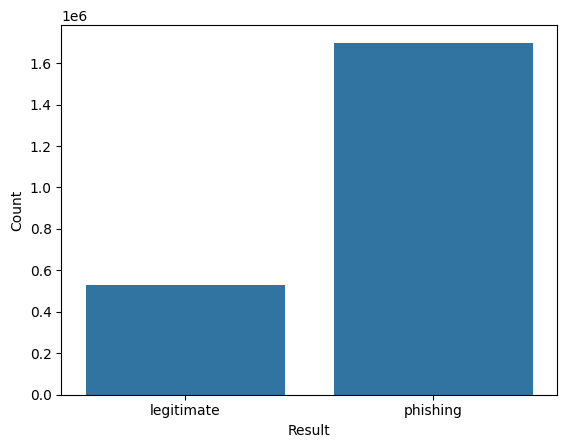

In [ ]:
print(df['Label'].value_counts())
sns.countplot(x='Label', data=df)
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

## **Heat Map**

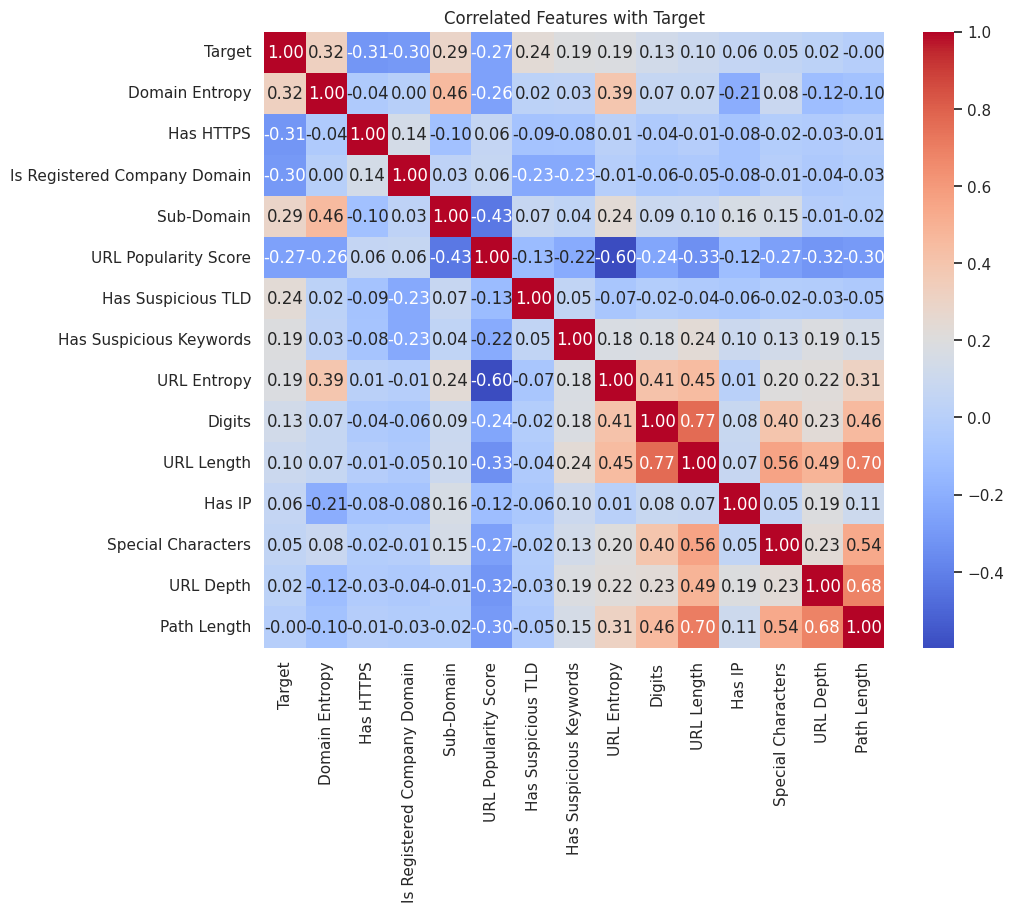

In [57]:
numeric_data = df.select_dtypes(include=[float, int])

correlations_ndata = numeric_data.corr()

# Identify the top features with the highest absolute correlation with the target
top_corr_features = correlations_ndata['Target'].abs().sort_values(ascending=False).head(16).index

# Plot correlation heatmap for the selected top features
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlated Features with Target")
plt.show()

# **Handle Missing Values**

In [12]:
df['TLD'] = df['TLD'].fillna(df[df['Target'] == 1]['TLD'].mode()[0])
df['URL Domain'] = df['URL Domain'].fillna(df[df['Target'] == 1]['URL Domain'].mode()[0])

In [13]:
df.isna().sum()

,0
URL,0
URL Length,0
Digits,0
URL Depth,0
URL Entropy,0
URL Popularity Score,0
URL Domain,0
Sub-Domain,0
Domain Entropy,0
Is Registered Company Domain,0


# **Encode Yes/No to 1/0**

In [14]:
label_cols = ['Is Registered Company Domain', 'Has HTTPS', 'Has IP', 'Has Suspicious Keywords', 'Has Suspicious TLD']
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [15]:
df

,URL,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Is Registered Company Domain,Path Length,Special Characters,Has HTTPS,Has IP,Has Suspicious Keywords,TLD,Has Suspicious TLD,Label,Target
0,https://google.com,18,0,0,3.6,15,google.com,0,2.6,1,0,2,1,0,0,com,0,legitimate,0
1,https://youtube.com,19,0,0,3.7,15,youtube.com,0,3.1,1,0,2,1,0,0,com,0,legitimate,0
2,https://facebook.com,20,0,0,3.8,13,facebook.com,0,3.0,1,0,2,1,0,0,com,0,legitimate,0
3,https://baidu.com,17,0,0,3.9,15,baidu.com,0,3.2,1,0,2,1,0,0,com,0,legitimate,0
4,https://wikipedia.org,21,0,0,3.9,13,wikipedia.org,0,3.3,1,0,2,1,0,0,org,0,legitimate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2225972,https://secure.kwsp.gov.my/member/login,39,0,2,4.3,6,secure.kwsp.gov.my,2,3.7,1,13,4,1,0,1,my,0,legitimate,0
2225973,https://login.yahoo.com,23,0,0,3.8,12,login.yahoo.com,1,3.2,1,0,3,1,0,0,com,0,legitimate,0
2225974,https://accounts.zoho.com/login,31,0,1,3.9,7,accounts.zoho.com,1,3.2,1,6,3,1,0,1,com,0,legitimate,0
2225975,https://mail.protonmail.com/login,33,0,1,3.8,7,mail.protonmail.com,1,3.3,1,6,3,1,0,0,com,0,legitimate,0


# **Balance Dataset**

In [16]:
legit_df = df[df['Target'] == 0]
phishing_df = df[df['Target'] == 1].sample(n=len(legit_df), random_state=42)
df_bal = pd.concat([phishing_df, legit_df], axis=0).reset_index(drop=True)

In [17]:
df_bal.drop_duplicates(inplace=True)

In [18]:
print("Balanced Dataset Class Distribution:")
print(df_bal['Target'].value_counts())

Balanced Dataset Class Distribution:
Target
0    527710
1    527708
Name: count, dtype: int64


# **Data Visualize**

In [56]:
for feature in ['Has HTTPS', 'Has IP', 'Has Suspicious Keywords', 'Has Suspicious TLD']:
    print(f"\n📊 {feature} by Label:")
    print(pd.crosstab(df_bal[feature], df_bal['Target'], colnames=["Label"], rownames=[feature]))


📊 Has HTTPS by Label:
Label           0       1
Has HTTPS                
0           55750  244176
1          471960  283532

📊 Has IP by Label:
Label        0       1
Has IP                
0       527707  518809
1            3    8899

📊 Has Suspicious Keywords by Label:
Label                         0       1
Has Suspicious Keywords                
0                        523380  446254
1                          4330   81454

📊 Has Suspicious TLD by Label:
Label                    0       1
Has Suspicious TLD                
0                   514960  400430
1                    12750  127278


## **Original vs Balanced**

📊 Target Distribution (Original Dataset):

Target
1    1698267
0     527710
Name: count, dtype: int64

📊 Target Distribution (Balanced Dataset):

Target
0    527710
1    527708
Name: count, dtype: int64


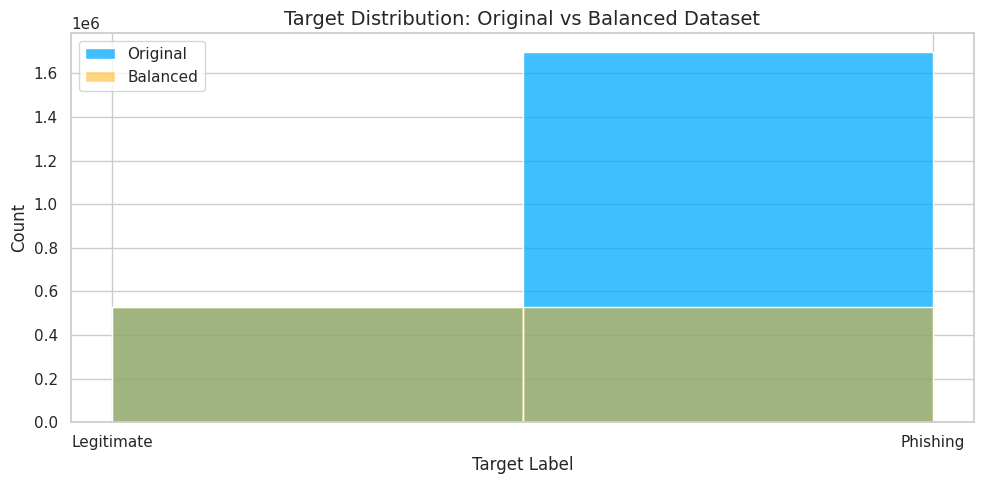

In [50]:
print("📊 Target Distribution (Original Dataset):\n")
print(df['Target'].value_counts())

print("\n📊 Target Distribution (Balanced Dataset):\n")
print(df_bal['Target'].value_counts())

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Target'], color="#00aaff", kde=False, label='Original', bins=2)
sns.histplot(df_bal['Target'], color="#ffaa00", kde=False, label='Balanced', bins=2, alpha=0.5)
plt.title('Target Distribution: Original vs Balanced Dataset', fontsize=14)
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.xlabel('Target Label')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## **HTTPS Usage by Label**

In [51]:
print("📊 HTTPS Usage by Label:\n")
print(pd.crosstab(df_bal['Has HTTPS'], df_bal['Target'], colnames=["Label"], rownames=["Has HTTPS"]))

📊 HTTPS Usage by Label:

Label           0       1
Has HTTPS                
0           55750  244176
1          471960  283532


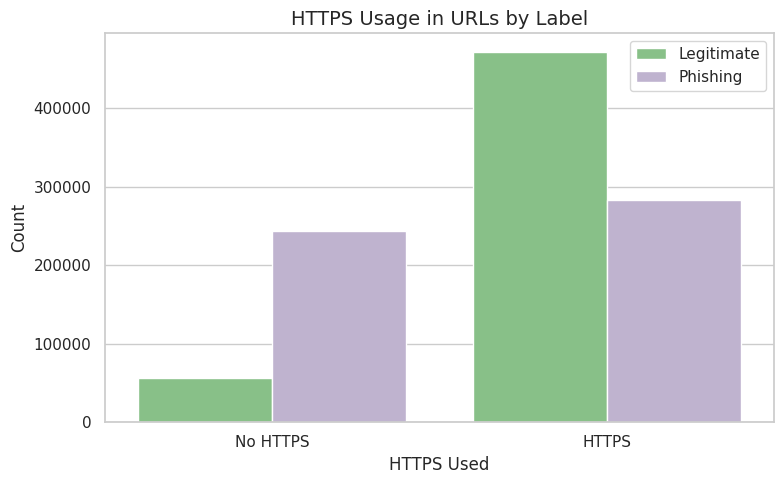

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Has HTTPS', hue='Target', data=df_bal, palette='Accent')
plt.title('HTTPS Usage in URLs by Label', fontsize=14)
plt.xticks([0, 1], ["No HTTPS", "HTTPS"])
plt.xlabel("HTTPS Used")
plt.ylabel("Count")
plt.legend(labels=["Legitimate", "Phishing"])
plt.tight_layout()
plt.show()

## **IP Address Usage by Label**

In [54]:
print("📊 IP Address Presence by Label:\n")
print(pd.crosstab(df_bal['Has IP'], df_bal['Target'], colnames=["Label"], rownames=["Has IP"]))

📊 IP Address Presence by Label:

Label        0       1
Has IP                
0       527707  518809
1            3    8899


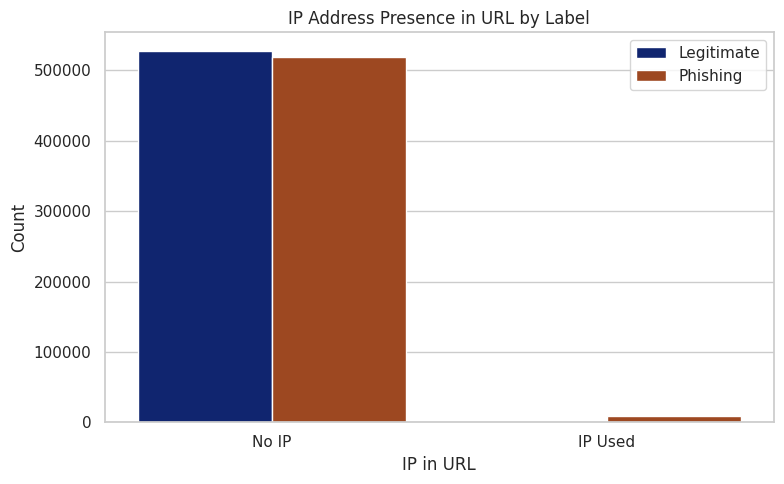

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Has IP', hue='Target', data=df_bal, palette='dark')
plt.title('IP Address Presence in URL by Label')
plt.xticks([0, 1], ['No IP', 'IP Used'])
plt.xlabel("IP in URL")
plt.ylabel("Count")
plt.legend(labels=['Legitimate', 'Phishing'])
plt.tight_layout()
plt.show()

## **Number of Digits in URL vs Label**

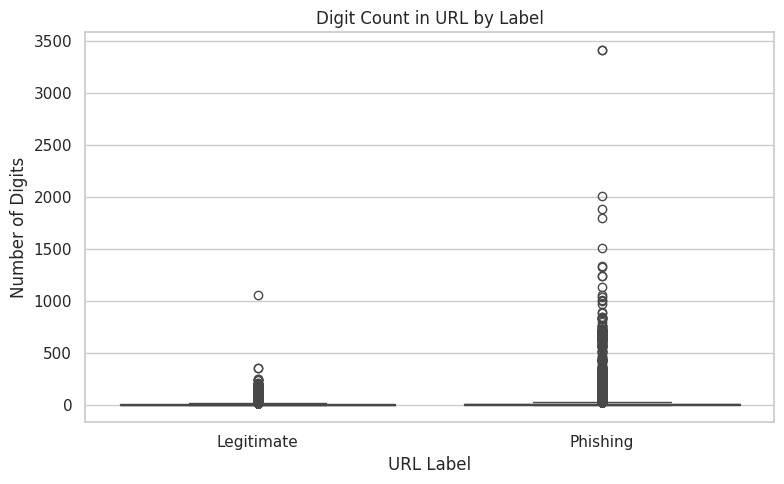

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='Digits', data=df_bal, palette='Set1')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Digit Count in URL by Label')
plt.xlabel("URL Label")
plt.ylabel("Number of Digits")
plt.tight_layout()
plt.show()

## **Special Characters in URL vs Label**

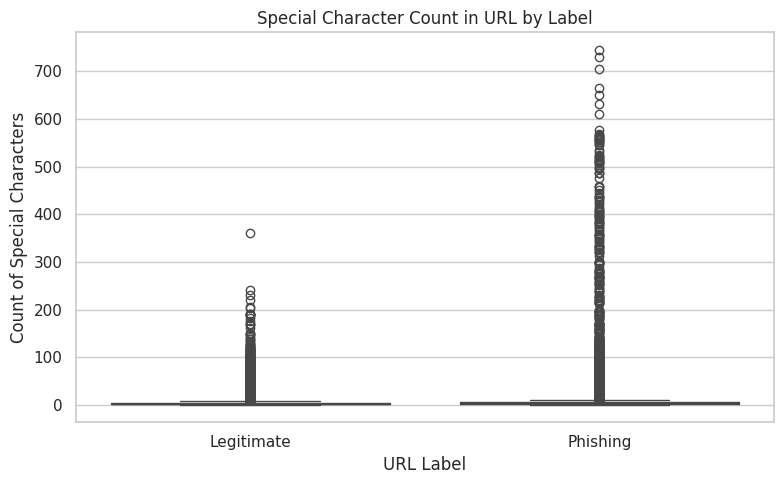

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='Special Characters', data=df_bal, palette='YlOrBr')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Character Count in URL by Label')
plt.xlabel("URL Label")
plt.ylabel("Count of Special Characters")
plt.tight_layout()
plt.show()

## **Suspicious Keyword Presence vs Label**

In [53]:
print("📊 Suspicious Keyword Presence by Label:\n")
print(pd.crosstab(df_bal['Has Suspicious Keywords'], df_bal['Target'], colnames=["Label"], rownames=["Has Suspicious Keyword"]))

📊 Suspicious Keyword Presence by Label:

Label                        0       1
Has Suspicious Keyword                
0                       523380  446254
1                         4330   81454


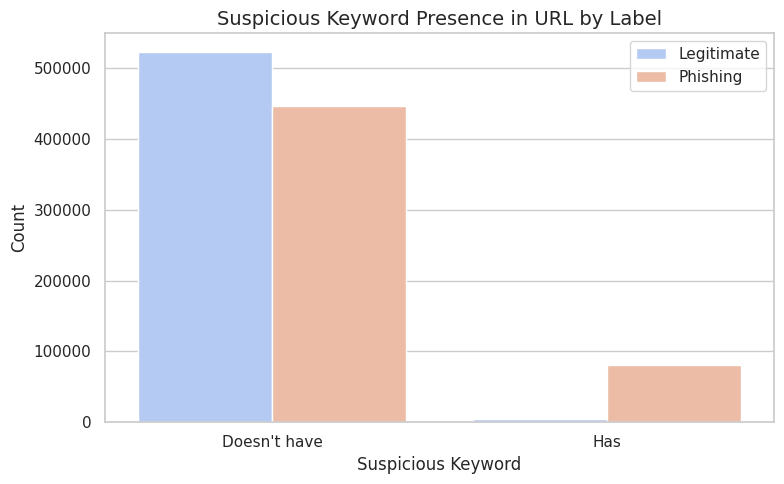

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Has Suspicious Keywords', hue='Target', data=df_bal, palette='coolwarm')
plt.title('Suspicious Keyword Presence in URL by Label', fontsize=14)
plt.xticks([0, 1], ["Doesn't have", 'Has'])
plt.xlabel("Suspicious Keyword")
plt.ylabel("Count")
plt.legend(labels=["Legitimate", "Phishing"])
plt.tight_layout()
plt.show()

## **Suspicious TLD Presence vs Label**

In [55]:
print("📊 Suspicious TLD Presence by Label:\n")
print(pd.crosstab(df_bal['Has Suspicious TLD'], df_bal['Target'], colnames=["Label"], rownames=["Suspicious TLD"]))

📊 Suspicious TLD Presence by Label:

Label                0       1
Suspicious TLD                
0               514960  400430
1                12750  127278


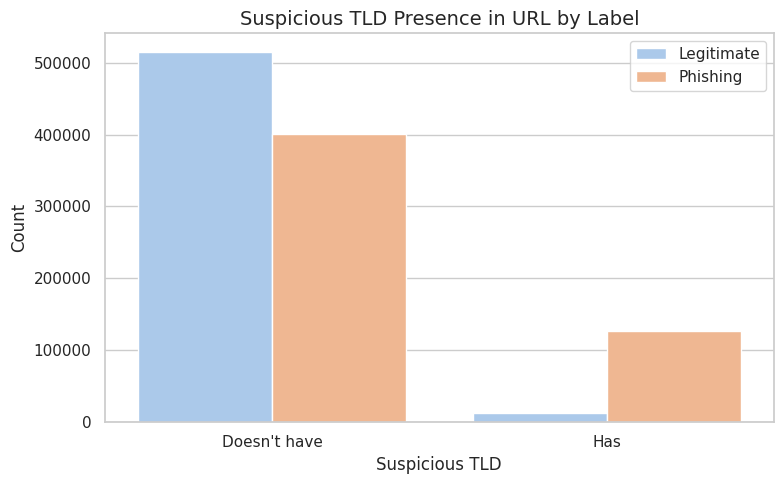

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Has Suspicious TLD', hue='Target', data=df_bal, palette='pastel')
plt.title('Suspicious TLD Presence in URL by Label', fontsize=14)
plt.xticks([0, 1], ["Doesn't have", 'Has'])
plt.xlabel("Suspicious TLD")
plt.ylabel("Count")
plt.legend(labels=["Legitimate", "Phishing"])
plt.tight_layout()
plt.show()

## **URL Length Distribution with KDE**

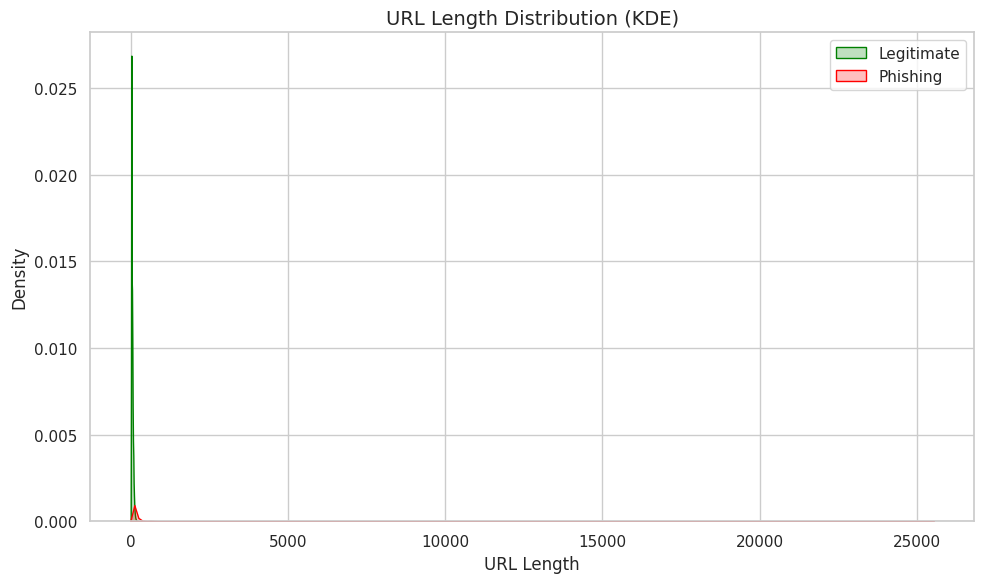

In [41]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_bal[df_bal['Target']==0]['URL Length'], label='Legitimate', fill=True, color='green')
sns.kdeplot(df_bal[df_bal['Target']==1]['URL Length'], label='Phishing', fill=True, color='red')
plt.title('URL Length Distribution (KDE)', fontsize=14)
plt.xlabel('URL Length')
plt.legend()
plt.tight_layout()
plt.show()

## **Domain Entropy Distribution**

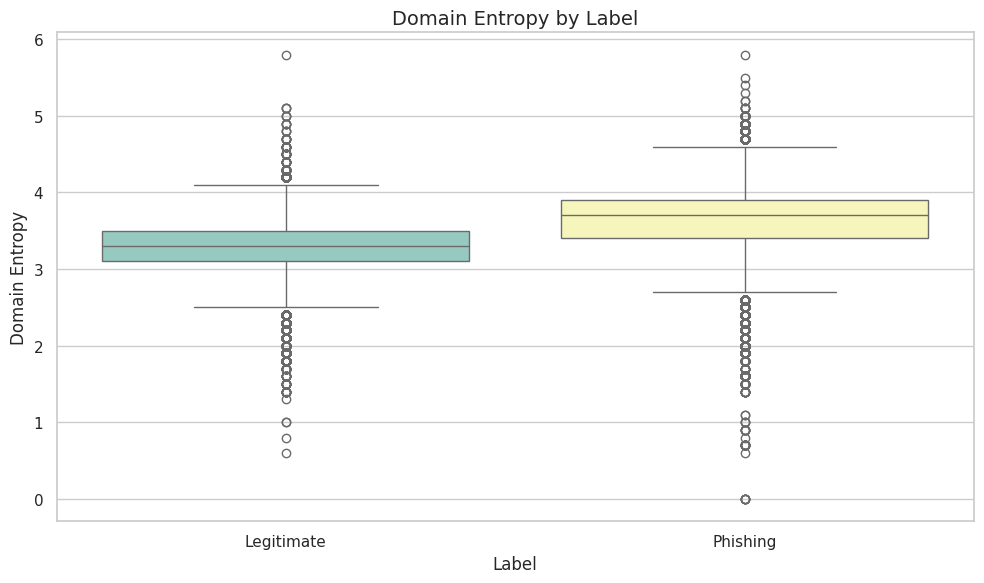

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='Domain Entropy', data=df_bal, palette='Set3')
plt.title("Domain Entropy by Label", fontsize=14)
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.xlabel("Label")
plt.tight_layout()
plt.show()

## **URL Length vs Label**

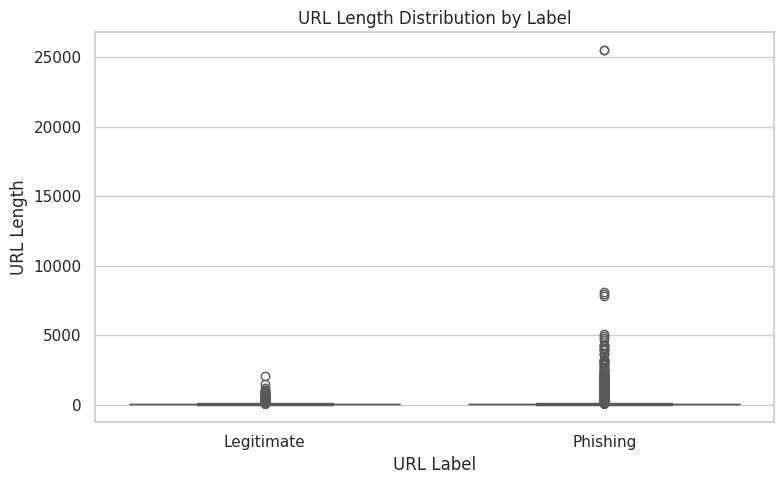

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='URL Length', data=df_bal, palette='Set2')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('URL Length Distribution by Label')
plt.xlabel("URL Label")
plt.ylabel("URL Length")
plt.tight_layout()
plt.show()

## **URL Depth vs Label**

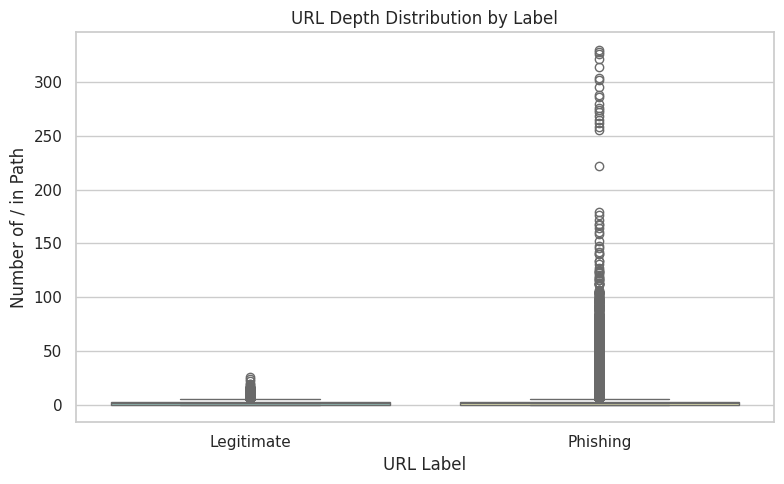

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='URL Depth', data=df_bal, palette='Set3')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('URL Depth Distribution by Label')
plt.xlabel("URL Label")
plt.ylabel("Number of / in Path")
plt.tight_layout()
plt.show()

## **URL Entropy vs Label**

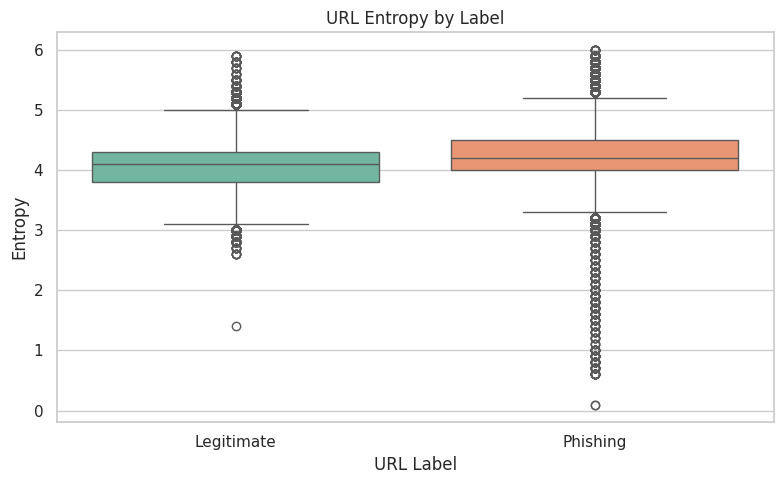

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='URL Entropy', data=df_bal, palette='Set2')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('URL Entropy by Label')
plt.xlabel("URL Label")
plt.ylabel("Entropy")
plt.tight_layout()
plt.show()

## **Path Length vs Label**

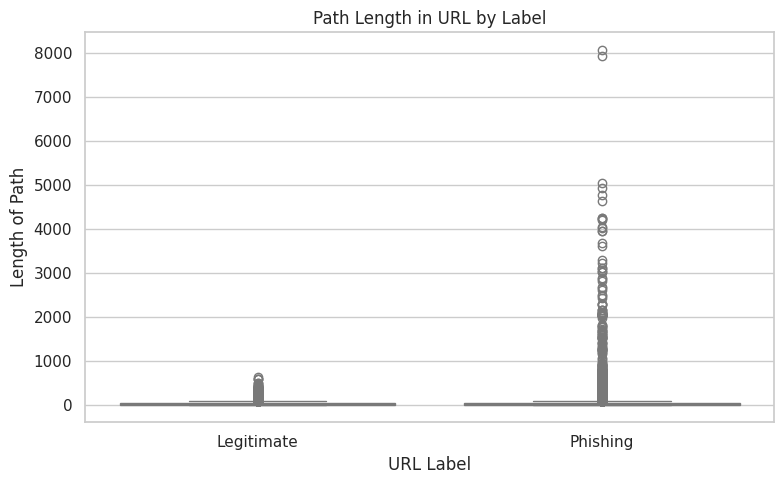

In [46]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='Path Length', data=df_bal, palette='coolwarm')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Path Length in URL by Label')
plt.xlabel("URL Label")
plt.ylabel("Length of Path")
plt.tight_layout()
plt.show()

## **Domain Registration Status vs Label**

📊 Domain Registration Status by URL Label (Balanced Data):

Is Registered Company Domain       0       1
Target                                      
Legitimate                    219205  308505
Phishing                      394065  133643


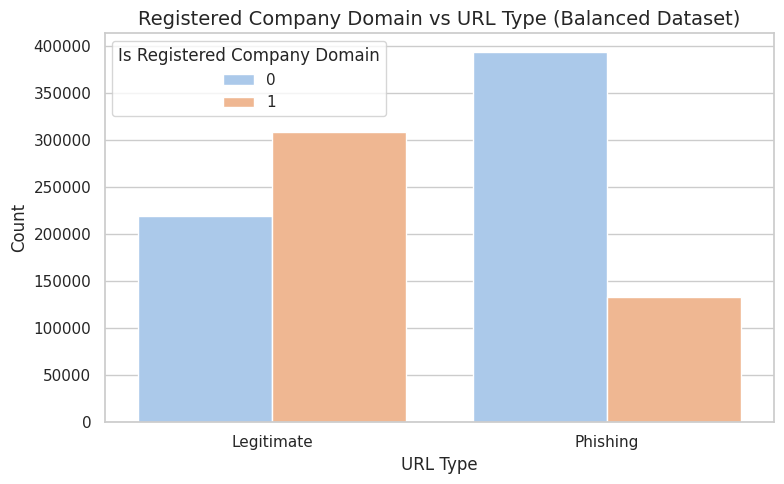

In [47]:
counts_bal = df_bal.groupby(['Target', 'Is Registered Company Domain']).size().unstack().fillna(0)

# Rename for clarity
counts_bal.index = counts_bal.index.map({0: 'Legitimate', 1: 'Phishing'})

print("📊 Domain Registration Status by URL Label (Balanced Data):\n")
print(counts_bal)

# Visualize
plt.figure(figsize=(8, 5))
sns.barplot(
    data=counts_bal.reset_index().melt(id_vars='Target'),
    x='Target', y='value', hue='Is Registered Company Domain', palette='pastel'
)
plt.title("Registered Company Domain vs URL Type (Balanced Dataset)", fontsize=14)
plt.xlabel("URL Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [19]:
X = df_bal.drop(columns=['Target', 'URL', 'URL Domain', 'Label'])
y = df_bal['Target']

# Encode TLD
tld_encoder = LabelEncoder()
X['TLD'] = tld_encoder.fit_transform(X['TLD'].astype(str))

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if not os.path.exists('models'):
    os.makedirs('models')

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'models/feature_order.pkl')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Save encoders
if not os.path.exists('models'):
    os.makedirs('models')
joblib.dump(tld_encoder, 'models/label_encoder.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

# **Model Training**

In [20]:
model_results = []

# Utility function to evaluate and store results
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n🔸 {name}")
    print(classification_report(y_test, y_pred))

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="YlGnBu")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    model_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred)
    })

## **Random Forest**

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


🔸 Random Forest
              precision    recall  f1-score   support

           0       0.93      0.94      0.93    158296
           1       0.94      0.93      0.93    158330

    accuracy                           0.93    316626
   macro avg       0.93      0.93      0.93    316626
weighted avg       0.93      0.93      0.93    316626



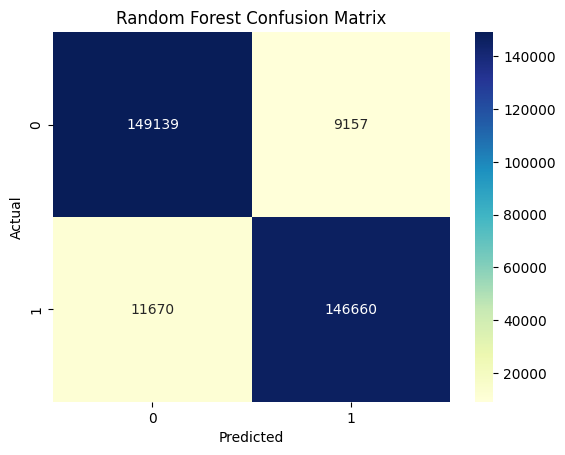

In [22]:
evaluate_model("Random Forest", rf_model, X_test, y_test)

In [23]:
joblib.dump(rf_model, 'models/random_forest_model.pkl')

['models/random_forest_model.pkl']

## **Calibrated Random Forest**

In [24]:
# Step 1: Define and fit the base model
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 2: Wrap with CalibratedClassifierCV
calibrated_rf = CalibratedClassifierCV(rf_base, method='isotonic', cv=5)  # or method='sigmoid' for faster training
calibrated_rf.fit(X_train, y_train)

# Step 3: Predict as usual
y_pred_rf = calibrated_rf.predict(X_test)


🔸 Calibrated Random Forest
              precision    recall  f1-score   support

           0       0.93      0.94      0.94    158296
           1       0.94      0.93      0.93    158330

    accuracy                           0.93    316626
   macro avg       0.93      0.93      0.93    316626
weighted avg       0.93      0.93      0.93    316626



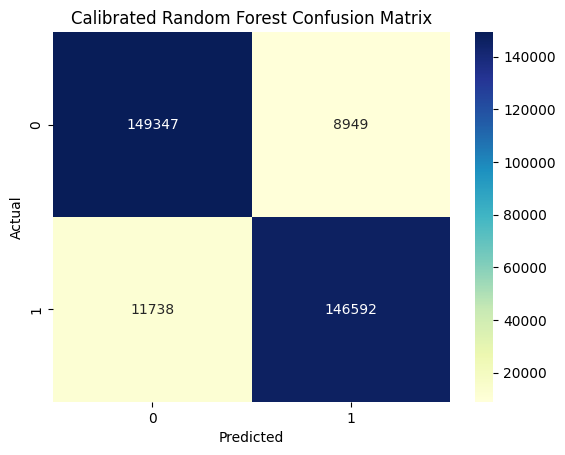

In [25]:
evaluate_model("Calibrated Random Forest", calibrated_rf, X_test, y_test)

In [26]:
joblib.dump(calibrated_rf, 'models/calibrated_random_forest_model.pkl')

['models/calibrated_random_forest_model.pkl']

## **Logistic Regression**

In [ ]:
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)

y_pred_log = logreg_model.predict(X_test)


🔸 Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.89      0.86    158296
           1       0.88      0.82      0.85    158330

    accuracy                           0.85    316626
   macro avg       0.85      0.85      0.85    316626
weighted avg       0.85      0.85      0.85    316626



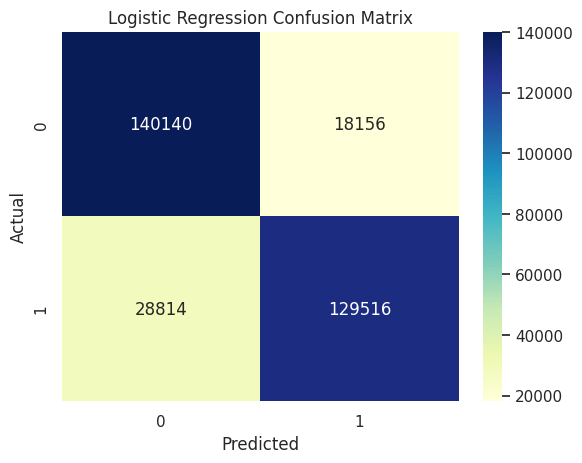

In [ ]:
evaluate_model("Logistic Regression", logreg_model, X_test, y_test)

In [ ]:
joblib.dump(logreg_model, 'models/logistic_regression_model.pkl')

['models/logistic_regression_model.pkl']

## **XGBoost**

In [ ]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:41:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🔸 XGBoost
              precision    recall  f1-score   support

           0       0.92      0.94      0.93    158296
           1       0.94      0.92      0.93    158330

    accuracy                           0.93    316626
   macro avg       0.93      0.93      0.93    316626
weighted avg       0.93      0.93      0.93    316626



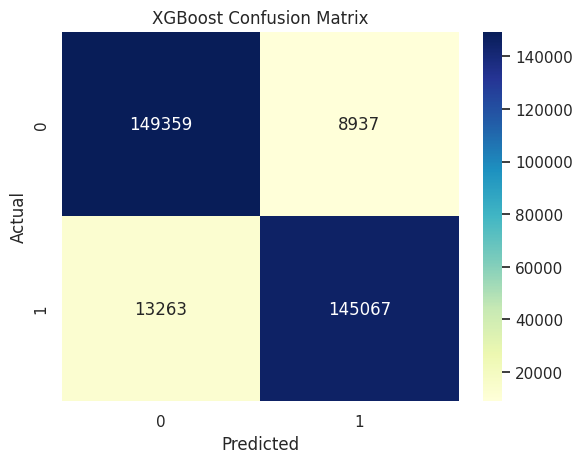

In [ ]:
evaluate_model("XGBoost", xgb_model, X_test, y_test)

In [ ]:
joblib.dump(xgb_model, 'models/xgboost_model.pkl')

['models/xgboost_model.pkl']

## **Naive Bayes**

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)


🔸 Naive Bayes
              precision    recall  f1-score   support

           0       0.64      0.95      0.77    158296
           1       0.90      0.48      0.62    158330

    accuracy                           0.71    316626
   macro avg       0.77      0.71      0.70    316626
weighted avg       0.77      0.71      0.70    316626



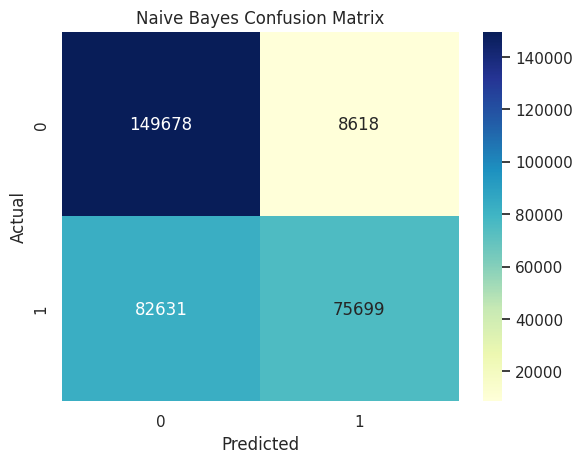

In [ ]:
evaluate_model("Naive Bayes", nb_model, X_test, y_test)

In [ ]:
joblib.dump(nb_model, 'models/naive_bayes_model.pkl')

['models/naive_bayes_model.pkl']

## **Gradient Boosting**


🔸 Gradient Boosting
              precision    recall  f1-score   support

           0       0.88      0.91      0.90    158296
           1       0.91      0.87      0.89    158330

    accuracy                           0.89    316626
   macro avg       0.89      0.89      0.89    316626
weighted avg       0.89      0.89      0.89    316626



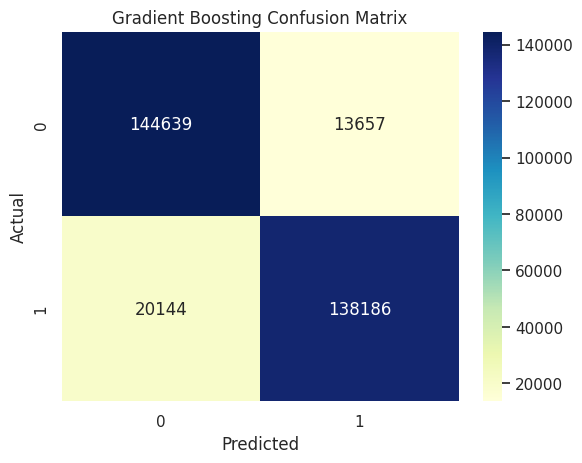

['models/gradient_boosting_model.pkl']

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
evaluate_model("Gradient Boosting", gb_model, X_test, y_test)
joblib.dump(gb_model, 'models/gradient_boosting_model.pkl')

## **K-Nearest Neighbors (KNN)**


🔸 K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.91      0.93      0.92    158296
           1       0.93      0.91      0.92    158330

    accuracy                           0.92    316626
   macro avg       0.92      0.92      0.92    316626
weighted avg       0.92      0.92      0.92    316626



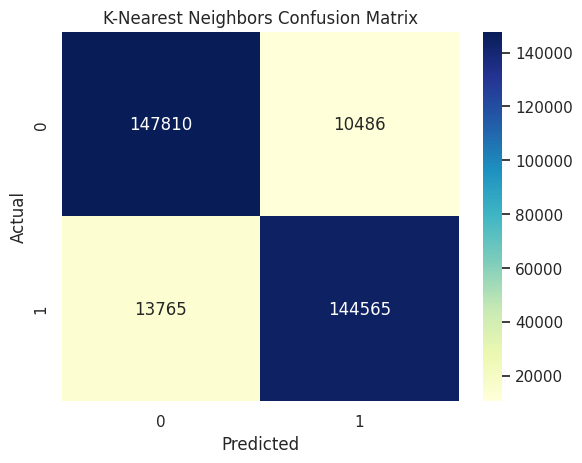

['models/knn_model.pkl']

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
evaluate_model("K-Nearest Neighbors", knn_model, X_test, y_test)
joblib.dump(knn_model, 'models/knn_model.pkl')

## **Voting Classifier (Ensemble)**

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:59:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🔸 Voting Classifier
              precision    recall  f1-score   support

           0       0.92      0.94      0.93    158296
           1       0.94      0.92      0.93    158330

    accuracy                           0.93    316626
   macro avg       0.93      0.93      0.93    316626
weighted avg       0.93      0.93      0.93    316626



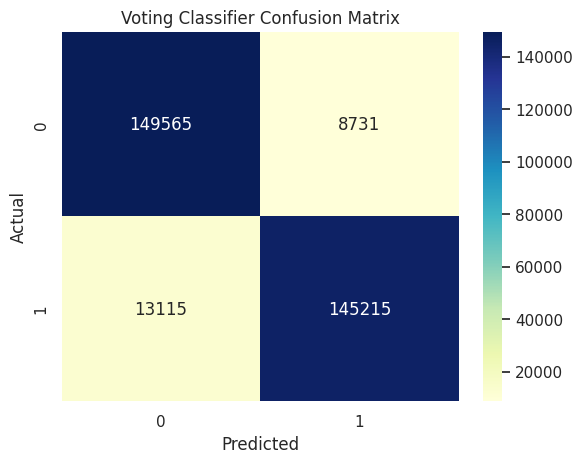

['models/voting_model.pkl']

In [ ]:
voting_model = VotingClassifier(estimators=[
    ('rf', calibrated_rf),
    ('xgb', xgb_model),
    ('lr', logreg_model)
], voting='soft')

voting_model.fit(X_train, y_train)
evaluate_model("Voting Classifier", voting_model, X_test, y_test)
joblib.dump(voting_model, 'models/voting_model.pkl')

# **Model Performance**

In [ ]:
# Convert to DataFrame
results_df = pd.DataFrame(model_results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display final results
print("\n📋 Final Model Performance Summary:")
print(results_df)


📋 Final Model Performance Summary:
                      Model  Accuracy  F1 Score    Recall  Precision
0  Calibrated Random Forest  0.934664  0.934091  0.925864   0.942465
1             Random Forest  0.934222  0.933703  0.926293   0.941232
2         Voting Classifier  0.931004  0.930043  0.917167   0.943285
3                   XGBoost  0.929886  0.928922  0.916232   0.941969
4       K-Nearest Neighbors  0.923408  0.922615  0.913061   0.932371
5         Gradient Boosting  0.893246  0.891025  0.872772   0.910058
6       Logistic Regression  0.851655  0.846504  0.818013   0.877052
7               Naive Bayes  0.711808  0.623943  0.478109   0.897790


In [ ]:
# Print class distribution in training set
print("🔹 Training Set Distribution:")
print(y_train.value_counts())
print()

# Print class distribution in test set
print("🔹 Test Set Distribution:")
print(y_test.value_counts())
print()


🔹 Training Set Distribution:
Target
0    369414
1    369378
Name: count, dtype: int64

🔹 Test Set Distribution:
Target
1    158330
0    158296
Name: count, dtype: int64



# **Features Importance**

🔍 Random Forest Feature Importances:

                         Feature  Importance
10                     Has HTTPS    0.122123
6                 Domain Entropy    0.121139
13                           TLD    0.089809
7   Is Registered Company Domain    0.087031
5                     Sub-Domain    0.085476
0                     URL Length    0.075269
1                         Digits    0.064120
8                    Path Length    0.061193
14            Has Suspicious TLD    0.060316
4           URL Popularity Score    0.058821
9             Special Characters    0.051243
3                    URL Entropy    0.048728
12       Has Suspicious Keywords    0.039347
2                      URL Depth    0.034837
11                        Has IP    0.000549


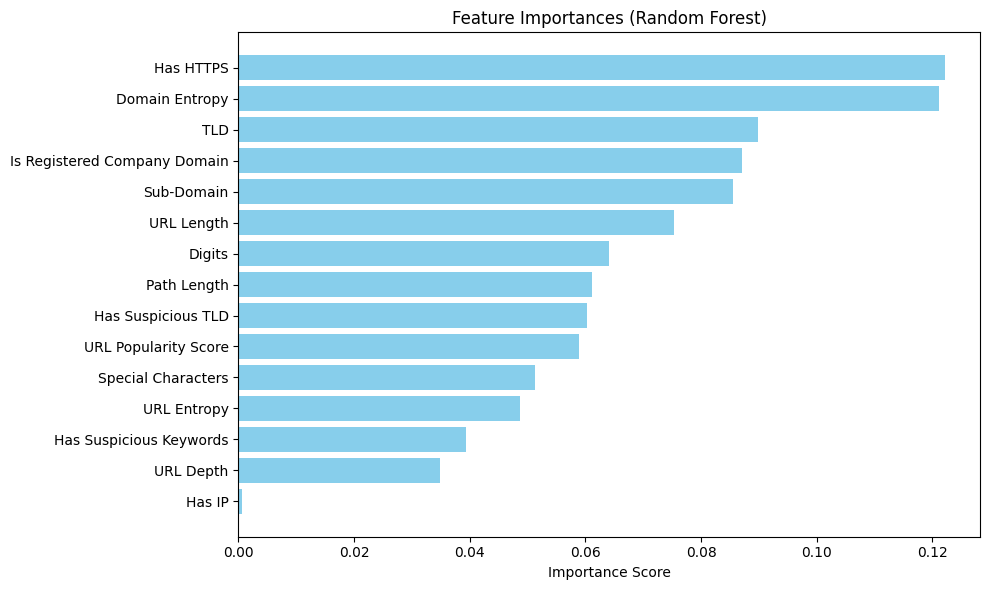

In [30]:
feature_names = X.columns.tolist()

# 🎯 Get importance scores
importances = rf_model.feature_importances_

# Combine with names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 🖨️ Print top features
print("🔍 Random Forest Feature Importances:\n")
print(importance_df)

# 📊 Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(17)[::-1], importance_df['Importance'].head(17)[::-1], color='skyblue')
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

🔍 XGBoost Feature Importances:

                         Feature  Importance
12       Has Suspicious Keywords    0.186185
14            Has Suspicious TLD    0.180109
7   Is Registered Company Domain    0.166088
5                     Sub-Domain    0.125081
10                     Has HTTPS    0.120348
6                 Domain Entropy    0.060627
1                         Digits    0.025469
13                           TLD    0.023689
4           URL Popularity Score    0.023282
9             Special Characters    0.022534
8                    Path Length    0.017892
2                      URL Depth    0.016609
0                     URL Length    0.015222
3                    URL Entropy    0.012808
11                        Has IP    0.004056


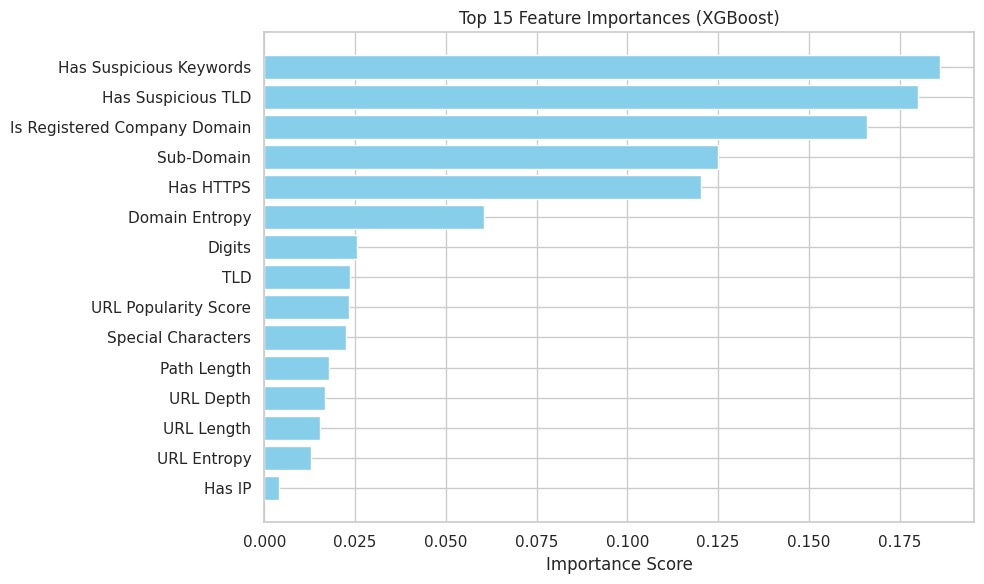

In [ ]:
feature_names = X.columns.tolist()

# 🎯 Get importance scores
importances = xgb_model.feature_importances_

# Combine with names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 🖨️ Print top features
print("🔍 XGBoost Feature Importances:\n")
print(importance_df)

# 📊 Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(15)[::-1], importance_df['Importance'].head(15)[::-1], color='skyblue')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()